# Chapter 05. Attention: Window or Mirage?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammadi-hadi/hands-on-xai-labs/blob/main/notebooks/ch05-attention.ipynb)

Companion notebook for Chapter 05 of *Hands-On Explainable AI*.

**What you'll build:** you load the Chapter 4 hate-speech specimen (DistilBERT fine-tuned on HatEval) and put its attention maps on trial. First you read a raw [CLS]-to-token map the way most blog posts do. Then you show that three equally defensible aggregations of the *same* tweet tell three different stories. You implement attention rollout from scratch (~15 lines), measure how well raw and rolled-out attention agree with Integrated Gradients across held-out tweets (Spearman ρ, real numbers), and run the Jain–Wallace teaching demo: ablate the most-attended heads and discover that the prediction survives, and so, mostly, does the map (a redundancy the debate rarely advertises). You leave with a five-test admissibility checklist for attention maps, scored live against this model.

This lab is part of *Hands-On Explainable AI: Interpreting, Evaluating, and Trusting Large Language Models* by [Hadi Mohammadi](https://mohammadi.cv). Code is MIT licensed; the repository and citation info live at [hands-on-xai-labs](https://github.com/mohammadi-hadi/hands-on-xai-labs) (DOI: [10.5281/zenodo.21804605](https://doi.org/10.5281/zenodo.21804605)).

In [1]:
%%capture
import importlib.util
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    %pip install -q transformers==4.57.6 datasets==3.6.0 captum==0.9.0 bertviz==1.4.1

In [2]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

SMOKE = os.environ.get("BOOK_SMOKE") == "1"
DEVICE = os.environ.get("BOOK_DEVICE") or (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

_style = Path("../styles/book.mplstyle")
if _style.exists():
    plt.style.use(_style)
INK, RUST, TEAL, AMBER, ROSE, STONE = "#1A1C1E", "#9A3412", "#0D9488", "#F59E0B", "#E11D48", "#A8A29E"
CM_RUST = LinearSegmentedColormap.from_list("bk_rust", ["#FFFFFF", RUST])
CM_TEAL = LinearSegmentedColormap.from_list("bk_teal", ["#FFFFFF", TEAL])
CM_ROSE = LinearSegmentedColormap.from_list("bk_rose", ["#FFFFFF", ROSE])

print(f"device={DEVICE} smoke={SMOKE}")

device=mps smoke=False


::: {.callout-warning}
## Content note
This lab works with real tweets from the HatEval corpus (`tweet_eval/hate`), which contains hateful and abusive language directed at women and immigrants. The examples appear here as *data to be explained*, not as speech we endorse. If you prefer, swap in the milder inline fallback set defined below.
:::

In [3]:
# Held-out pool: the HatEval VALIDATION split. Chapter 4 measured a hard topic
# shift on the TEST split (the specimen predicts "hate" on ~96% of it, acc 0.460),
# so all example tweets in Part II come from validation, where the model behaves
# sanely (acc 0.676, macro-F1 0.676). Honest sourcing beats a prettier pool.
FALLBACK_TWEETS = [
    ("Women like her are too stupid to have opinions, send her back to the kitchen", 1),
    ("These illegals are invading us, deport every single one of them now", 1),
    ("She only got the job because she cried, typical hysterical woman", 1),
    ("Refugees are parasites draining this country dry, close the border", 1),
    ("Another woman driver, they should all have their licenses taken away", 1),
    ("Immigrants bring nothing but crime and disease, ship them all back", 1),
    ("Just finished a great book about the history of jazz piano", 0),
    ("The new immigration bill will be debated in parliament next week", 0),
    ("My grandmother still makes the best lasagna in the whole family", 0),
    ("Women's football is getting record audiences this season, deservedly so", 0),
    ("The refugee center is looking for volunteers to teach language classes", 0),
    ("Traffic was terrible this morning but the podcast made it bearable", 0),
]

try:
    from datasets import load_dataset

    _val = load_dataset("tweet_eval", "hate", split="validation")
    pool_texts, pool_golds = list(_val["text"]), list(_val["label"])
    print(f"HatEval validation split: {len(pool_texts)} tweets")
except Exception as exc:  # offline fallback keeps the notebook alive
    pool_texts = [t for t, _ in FALLBACK_TWEETS]
    pool_golds = [g for _, g in FALLBACK_TWEETS]
    print(f"datasets unavailable ({type(exc).__name__}), using {len(pool_texts)} inline tweets")

HatEval validation split: 1000 tweets


## Load the specimen

Same contract as every Part II chapter: `get_specimen()` loads the shared hate/sexism classifier that Chapter 4 fine-tuned and saved, or quick-trains a small stand-in so the notebook stays standalone on Colab. One difference here: we load with `attn_implementation="eager"`, because the fused SDPA kernels don't return per-head attention weights, and this whole chapter is about those weights.

In [4]:
SPECIMEN_DIR = Path("../models/ch04-specimen")


def get_specimen():
    """Load the Chapter 4 hate/sexism specimen; quick-train a small stand-in if absent
    (keeps this notebook standalone on Colab)."""
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    if SPECIMEN_DIR.exists():
        tok = AutoTokenizer.from_pretrained(SPECIMEN_DIR)
        mdl = AutoModelForSequenceClassification.from_pretrained(
            SPECIMEN_DIR, attn_implementation="eager"
        )
    else:
        # Quick-train fallback: prajjwal1/bert-mini on tweet_eval "hate"
        # (1500 train items, 2 epochs, lr 3e-5, max_len 96, batch 32), then save.
        base = "prajjwal1/bert-mini"
        tok = AutoTokenizer.from_pretrained(base)
        mdl = AutoModelForSequenceClassification.from_pretrained(
            base, num_labels=2,
            id2label={0: "not-hate", 1: "hate"}, label2id={"not-hate": 0, "hate": 1},
            attn_implementation="eager",
        )
        try:
            from datasets import load_dataset

            _tr = load_dataset("tweet_eval", "hate", split="train[:1500]")
            tr_texts, tr_labels = list(_tr["text"]), list(_tr["label"])
        except Exception:
            tr_texts = [t for t, _ in FALLBACK_TWEETS] * 40
            tr_labels = [g for _, g in FALLBACK_TWEETS] * 40
        mdl.to(DEVICE).train()
        opt = torch.optim.AdamW(mdl.parameters(), lr=3e-5)
        for _epoch in range(2):
            for i in range(0, len(tr_texts), 32):
                enc = tok(tr_texts[i:i + 32], truncation=True, max_length=96,
                          padding=True, return_tensors="pt").to(DEVICE)
                loss = mdl(**enc, labels=torch.tensor(tr_labels[i:i + 32]).to(DEVICE)).loss
                loss.backward(); opt.step(); opt.zero_grad()
        SPECIMEN_DIR.mkdir(parents=True, exist_ok=True)
        mdl.save_pretrained(SPECIMEN_DIR); tok.save_pretrained(SPECIMEN_DIR)
    mdl.to(DEVICE).eval()
    return tok, mdl


tok, model = get_specimen()
_probe = tok("a probe", return_tensors="pt").to(DEVICE)
with torch.no_grad():
    _out = model(**_probe, output_attentions=True)
NUM_LAYERS, NUM_HEADS = len(_out.attentions), _out.attentions[0].shape[1]
print(f"specimen: {model.config.model_type}, {NUM_LAYERS} layers x {NUM_HEADS} heads, labels={model.config.id2label}")

specimen: distilbert, 6 layers x 12 heads, labels={0: 'not-hate', 1: 'hate'}


In [5]:
@torch.no_grad()
def predict_proba(texts, batch_size=32):
    out = []
    for i in range(0, len(texts), batch_size):
        enc = tok(texts[i:i + batch_size], truncation=True, max_length=96,
                  padding=True, return_tensors="pt").to(DEVICE)
        out.append(model(**enc).logits.softmax(-1).cpu())
    return torch.cat(out).numpy()


POOL_N = 120 if SMOKE else 400
K = 3 if SMOKE else 8
K_HATE = 2 if SMOKE else 4

pool = pd.DataFrame({"text": pool_texts[:POOL_N], "gold": pool_golds[:POOL_N]})
pool["p_hate"] = predict_proba(pool["text"].tolist())[:, 1]
pool["n_words"] = pool["text"].str.split().str.len()
# readable examples: 6-24 words, no links, at most 2 hashtags (HatEval's most
# confident tweets are otherwise hashtag soup - a selection choice, disclosed)
ok = pool[pool["n_words"].between(6, 24) & ~pool["text"].str.contains("http")
          & (pool["text"].str.count("#") <= 2)]

picked = pd.concat([
    ok.sort_values("p_hate", ascending=False).head(K_HATE),   # confident hate
    ok.sort_values("p_hate", ascending=True).head(K - K_HATE),  # confident not-hate
]).reset_index(drop=True)
picked["pred"] = (picked["p_hate"] >= 0.5).astype(int)

with pd.option_context("display.max_colwidth", 70):
    print(picked[["text", "gold", "pred", "p_hate"]].round(3).to_string())

                                                                                                                                         text  gold  pred  p_hate
0                                                          @user @user Illegals too? #BuildThatWall #AmericaFirst God Bless America and @user     1     1   0.912
1  Molly Tibbetts murder is not a political issue its a law enforcement issue #BuildThatWall it saves American lives from criminals and drugs     1     1   0.908
2                                                        @user Stfu u hating ass bitch go suck her big dick pussy ass hoe u lookin like a rat     1     1   0.905
3                      @user Yeah but "Shakedown Schumer"& his buddies say we don't need a wall or borders! More evidence to #BuildThatWall !     1     1   0.898
4                        Go Denzil #ILCTRawards stirring presentation about immigrant entrepreneurs and their contributions @user @user @user     0     0   0.109
5                           

## Reading a raw attention map

The classification head reads exactly one vector: the final-layer `[CLS]` position. So the honest first question is *where does `[CLS]` look?* (the `[CLS]` row of the attention matrix). We take the last layer and average the heads, which is what most tutorials (and most screenshots in model cards) silently do. It produces a satisfying picture. Hold that feeling; the next section takes it apart.

In [6]:
def analyze(text):
    """Forward pass with attentions; returns tokens, (L,H,T,T) attention, probs, word_ids."""
    enc = tok(text, truncation=True, max_length=96, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model(**enc, output_attentions=True)
    return {
        "text": text,
        "enc": enc,
        "tokens": tok.convert_ids_to_tokens(enc["input_ids"][0]),
        "att": torch.stack([a[0].cpu() for a in out.attentions]),  # (L, H, T, T)
        "probs": out.logits.softmax(-1)[0].cpu().numpy(),
        "word_ids": enc.word_ids(0),
    }


def cls_row(att, layer=-1, agg="mean"):
    """[CLS]-to-token attention at one layer, aggregated over heads."""
    A = att[layer]  # (H, T, T)
    return (A.mean(0) if agg == "mean" else A.max(0).values)[0].numpy()


def content_idx(tokens):
    return [i for i, t in enumerate(tokens) if t not in ("[CLS]", "[SEP]")]


def strip(ax, tokens, weights, cmap, label, show_tokens=True):
    w = np.asarray(weights, dtype=float)
    w = w / (w.max() + 1e-12)  # each strip normalized to its own max
    ax.imshow(w[None, :], cmap=cmap, aspect="auto", vmin=0, vmax=1)
    ax.set_yticks([])
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens if show_tokens else [], rotation=60, ha="right", fontsize=11)
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=10)
    for s in ax.spines.values():
        s.set_visible(False)


records = [analyze(t) for t in picked["text"]]

# Showcase tweet: a confident predicted-hate pick with as much natural language
# (and as little hashtag/@ clutter) as possible.
_hate_recs = [r for r in records if r["probs"][1] >= 0.5 and 8 <= len(r["text"].split()) <= 24]
show = (min(_hate_recs, key=lambda r: (r["text"].count("#") + r["text"].count("@"), -r["probs"][1]))
        if _hate_recs else records[0])

# How much of [CLS]'s last-layer gaze lands on special tokens? (checklist test 5)
special_mass = []
for r in records:
    row = cls_row(r["att"])
    spec = [i for i, t in enumerate(r["tokens"]) if t in ("[CLS]", "[SEP]")]
    special_mass.append(float(row[spec].sum()))
SPECIAL_MASS = float(np.mean(special_mass))
print(f"showcase tweet (p_hate={show['probs'][1]:.3f}): {show['text']!r}")
print(f"mean [CLS]+[SEP] share of last-layer [CLS] attention over {len(records)} tweets: "
      f"{SPECIAL_MASS:.2f} (min {min(special_mass):.2f}, max {max(special_mass):.2f})")

showcase tweet (p_hate=0.908): 'Molly Tibbetts murder is not a political issue its a law enforcement issue #BuildThatWall it saves American lives from criminals and drugs'
mean [CLS]+[SEP] share of last-layer [CLS] attention over 8 tweets: 0.32 (min 0.08, max 0.67)


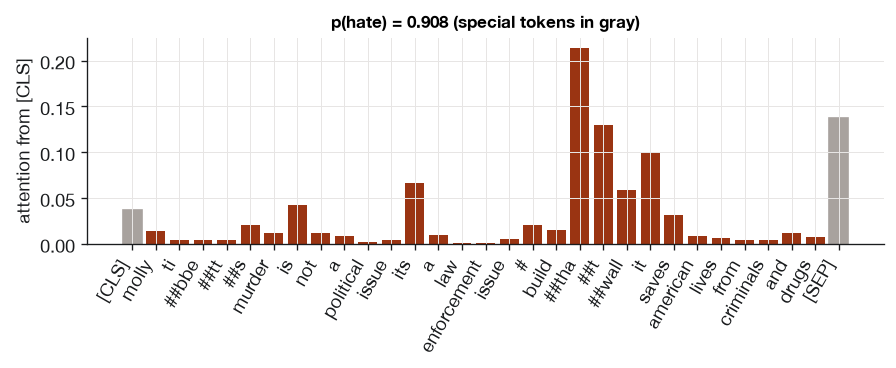

In [7]:
#| label: fig-attention-cls-bar
#| fig-cap: "[CLS]-to-token attention (last layer, head-averaged) for one confidently flagged tweet: the map everyone screenshots."
#| fig-alt: "Bar chart of last-layer CLS-to-token attention for one flagged tweet: a few tokens take most of the attention mass."
row = cls_row(show["att"])
fig, ax = plt.subplots(figsize=(7.6, 3.2))
bars = ax.bar(range(len(show["tokens"])), row, color=RUST)
for i, t in enumerate(show["tokens"]):
    if t in ("[CLS]", "[SEP]"):
        bars[i].set_color(STONE)
ax.set_xticks(range(len(show["tokens"])))
ax.set_xticklabels(show["tokens"], rotation=60, ha="right", fontsize=11)
ax.set_ylabel("attention from [CLS]")
ax.set_title(f"p(hate) = {show['probs'][1]:.3f} (special tokens in gray)", fontsize=10)
plt.tight_layout()
plt.show()

## The aggregation trap

"The" attention map does not exist. A transformer this small already has 72 maps per input (6 layers × 12 heads), and every heatmap you have ever seen chose one way to collapse them. Below: the *same tweet, same forward pass*, collapsed three defensible ways: last layer averaged over heads, last layer max over heads, and a middle layer averaged. If the three strips ranked the same tokens, aggregation would be a detail. We measure whether they do (Spearman ρ between strips, special tokens excluded).

In [8]:
L_LAST = NUM_LAYERS            # 1-indexed for labels
L_MID_IDX = NUM_LAYERS // 2 - 1  # e.g. layer 3 of 6
agg_rows = {
    f"layer {L_LAST} \u00b7 head mean": cls_row(show["att"], layer=-1, agg="mean"),
    f"layer {L_LAST} \u00b7 head max": cls_row(show["att"], layer=-1, agg="max"),
    f"layer {L_MID_IDX + 1} \u00b7 head mean": cls_row(show["att"], layer=L_MID_IDX, agg="mean"),
}

ci = content_idx(show["tokens"])
names = list(agg_rows)
agg_pair_rho = {}
for a in range(len(names)):
    for b in range(a + 1, len(names)):
        rho = spearmanr(agg_rows[names[a]][ci], agg_rows[names[b]][ci]).statistic
        agg_pair_rho[(names[a], names[b])] = rho
        print(f"Spearman rho  {names[a]}  vs  {names[b]}: {rho:.2f}")
AGG_RHO_MIN = min(agg_pair_rho.values())
print(f"\nworst pairwise agreement: rho = {AGG_RHO_MIN:.2f}, same tweet, same forward pass")

Spearman rho  layer 6 · head mean  vs  layer 6 · head max: 0.95
Spearman rho  layer 6 · head mean  vs  layer 3 · head mean: -0.15
Spearman rho  layer 6 · head max  vs  layer 3 · head mean: -0.21

worst pairwise agreement: rho = -0.21, same tweet, same forward pass


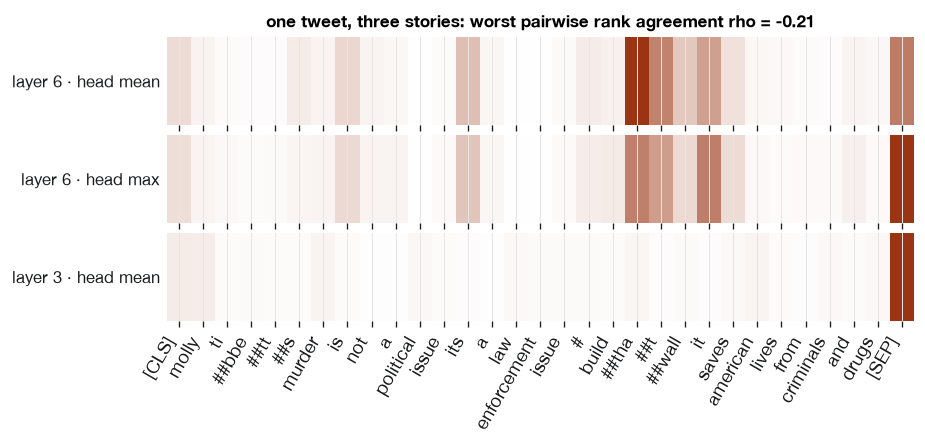

In [9]:
#| label: fig-attention-aggregation
#| fig-cap: "Three defensible aggregations of one tweet's attention rank the tokens differently. 'The' attention map is a choice, not a fact."
#| fig-alt: "Three bar charts of the same tweet's attention under three aggregation choices: the token ranking changes with each choice."
fig, axes = plt.subplots(3, 1, figsize=(7.6, 3.6), constrained_layout=True)
for ax, (name, w) in zip(axes, agg_rows.items()):
    strip(ax, show["tokens"], w, CM_RUST, name, show_tokens=(ax is axes[-1]))
axes[0].set_title(
    f"one tweet, three stories: worst pairwise rank agreement rho = {AGG_RHO_MIN:.2f}",
    fontsize=10)
plt.show()

## Attention rollout: following the whole ladder

A single layer's map answers the wrong question. By layer 6, each position's vector is already a mixture of every earlier token (Chapter 3's residual assembly line), so "[CLS] attends to *stupid*" really means "…to whatever *stupid*'s slot has become". **Attention rollout** [@abnar2020quantifying] is the cheapest correction: treat each layer's head-averaged matrix as a transition matrix, add the residual connection as `(A + I) / 2`, and multiply up through the layers. The product estimates how much of each *input* token survives into each final position. It is ~15 lines, and it visibly redistributes credit.

In [10]:
def attention_rollout(att):
    """att: (L, H, T, T) -> (T, T) rollout matrix. Row i = how much each input
    token feeds position i at the top of the stack (rows sum to 1)."""
    T = att.shape[-1]
    R = torch.eye(T)
    for layer_att in att:                      # bottom layer first
        A = layer_att.mean(0)                  # average heads -> (T, T)
        A = (A + torch.eye(T)) / 2             # residual connection
        A = A / A.sum(-1, keepdim=True)        # renormalize rows
        R = A @ R                              # compose with layers below
    return R


show["rollout"] = attention_rollout(show["att"])[0].numpy()  # [CLS] row
raw = cls_row(show["att"])


def top_tokens(weights, tokens, k=5):
    idx = [i for i in np.argsort(weights)[::-1] if tokens[i] not in ("[CLS]", "[SEP]")][:k]
    return [tokens[i] for i in idx]


print("top-5 by raw last-layer attention:", top_tokens(raw, show["tokens"]))
print("top-5 by rollout:                 ", top_tokens(show["rollout"], show["tokens"]))
ROLL_VS_RAW_RHO = spearmanr(raw[ci], show["rollout"][ci]).statistic
print(f"Spearman rho raw vs rollout (content tokens): {ROLL_VS_RAW_RHO:.2f}")

top-5 by raw last-layer attention: ['##tha', '##t', 'it', 'its', '##wall']
top-5 by rollout:                  ['and', 'a', '##tha', 'a', 'it']
Spearman rho raw vs rollout (content tokens): 0.66


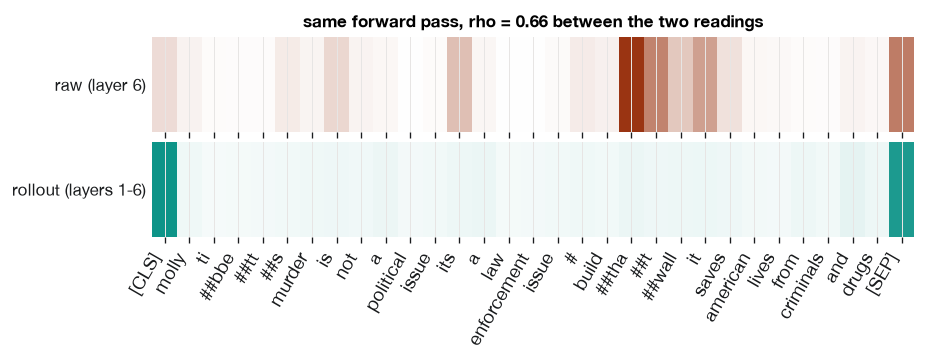

In [11]:
#| label: fig-attention-rollout
#| fig-cap: "Raw last-layer attention vs attention rollout on the same tweet: composing all six layers redistributes the credit."
#| fig-alt: "Two bar charts comparing raw last-layer attention with attention rollout for the same tweet: composing all layers redistributes the credit across tokens."
if SMOKE:
    print("smoke mode: skipping the rollout comparison grid")
else:
    fig, axes = plt.subplots(2, 1, figsize=(7.6, 2.9), constrained_layout=True)
    strip(axes[0], show["tokens"], raw, CM_RUST, "raw (layer 6)", show_tokens=False)
    strip(axes[1], show["tokens"], show["rollout"], CM_TEAL, "rollout (layers 1-6)")
    axes[0].set_title(
        f"same forward pass, rho = {ROLL_VS_RAW_RHO:.2f} between the two readings", fontsize=10)
    plt.show()

## Attention vs attribution: do they even agree?

If attention maps were reliable explanations, they should broadly agree with an attribution method computed on the *same model and input*. Integrated Gradients (Chapter 4's workhorse; same `[PAD]` baseline, same sub-word-to-word aggregation via `word_ids()`) gives us that reference. For each held-out tweet we compute the word-level Spearman ρ between |IG| and (a) raw last-layer attention, (b) rollout. The literature says these correlations are often mediocre [@jain2019attention; @wiegreffe2019attention]. We report whatever we measure. Attention is non-negative, so we compare against IG *magnitudes*: can attention at least find the important words, signs aside?

In [12]:
from captum.attr import LayerIntegratedGradients

IG_STEPS = 8 if SMOKE else 32
emb_layer = getattr(model, model.base_model_prefix).embeddings


def logits_fn(input_ids, attention_mask):
    return model(input_ids=input_ids, attention_mask=attention_mask).logits


lig = LayerIntegratedGradients(logits_fn, emb_layer)


def ig_token_scores(enc, target):
    """Per-token IG scores ([PAD] baseline, embedding dims summed) + convergence delta."""
    ids, mask = enc["input_ids"], enc["attention_mask"]
    base = torch.full_like(ids, tok.pad_token_id)
    base[0, 0], base[0, -1] = ids[0, 0], ids[0, -1]  # keep [CLS]/[SEP]
    attrs, delta = lig.attribute(inputs=ids, baselines=base,
                                 additional_forward_args=(mask,), target=target,
                                 n_steps=IG_STEPS, return_convergence_delta=True)
    return attrs.sum(-1)[0].detach().cpu().numpy(), float(abs(delta))


def to_word_scores(scores, word_ids):
    """Sum sub-word scores into words (same helper family as ch04)."""
    agg = {}
    for i, wid in enumerate(word_ids):
        if wid is not None:
            agg[wid] = agg.get(wid, 0.0) + float(scores[i])
    return np.array([agg[w] for w in sorted(agg)])


rho_rows, deltas = [], []
for r in records:
    target = int(r["probs"].argmax())
    ig, delta = ig_token_scores(r["enc"], target)
    deltas.append(delta)
    w_ig = np.abs(to_word_scores(ig, r["word_ids"]))
    w_raw = to_word_scores(cls_row(r["att"]), r["word_ids"])
    w_roll = to_word_scores(attention_rollout(r["att"])[0].numpy(), r["word_ids"])
    rho_rows.append({
        "raw (layer 6)": spearmanr(w_raw, w_ig).statistic,
        "rollout": spearmanr(w_roll, w_ig).statistic,
        "raw vs rollout": spearmanr(w_raw, w_roll).statistic,
    })
rho_df = pd.DataFrame(rho_rows)
print(rho_df.round(2).to_string())
print(f"\nmean rho vs |IG|: raw {rho_df['raw (layer 6)'].mean():.2f} "
      f"\u00b1 {rho_df['raw (layer 6)'].std():.2f} | rollout {rho_df['rollout'].mean():.2f} "
      f"\u00b1 {rho_df['rollout'].std():.2f}")
print(f"max IG convergence delta: {max(deltas):.3f} ({IG_STEPS} steps)")

   raw (layer 6)  rollout  raw vs rollout
0           0.82     0.65            0.82
1           0.06    -0.04            0.69
2          -0.16    -0.00            0.32
3           0.24     0.23            0.32
4          -0.50    -0.60            0.74
5          -0.31    -0.59            0.50
6           0.09     0.02            0.90
7          -0.15     0.27            0.72

mean rho vs |IG|: raw 0.01 ± 0.40 | rollout -0.01 ± 0.42
max IG convergence delta: 0.031 (32 steps)


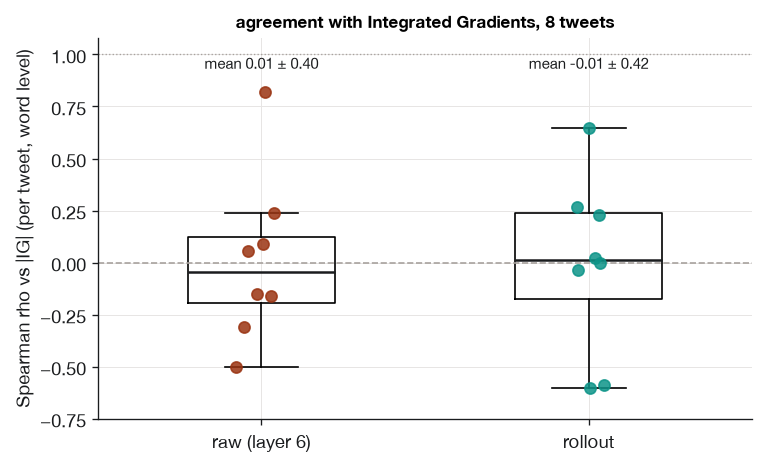

In [13]:
#| label: fig-attention-vs-ig
#| fig-cap: "Word-level Spearman correlation between attention (raw and rollout) and |Integrated Gradients| on held-out tweets: measured, not assumed."
#| fig-alt: "Distribution of word-level Spearman correlations between attention and Integrated Gradients magnitudes across held-out tweets: centered near zero with wide spread."
variants = ["raw (layer 6)", "rollout"]
data = [rho_df[v].values for v in variants]
fig, ax = plt.subplots(figsize=(6.5, 4))
bp = ax.boxplot(data, tick_labels=variants, widths=0.45, showfliers=False,
                medianprops={"color": INK, "linewidth": 1.5})
rng = np.random.default_rng(SEED)
for i, (vals, color) in enumerate(zip(data, [RUST, TEAL]), start=1):
    ax.scatter(rng.normal(i, 0.04, len(vals)), vals, s=45, color=color, alpha=0.85, zorder=3)
    ax.text(i, 1.0, f"mean {np.mean(vals):.2f} \u00b1 {np.std(vals, ddof=1):.2f}",
            fontsize=9, ha="center", va="top", color=INK)
ax.axhline(0, color=STONE, linestyle="--", linewidth=1)
ax.axhline(1, color=STONE, linestyle=":", linewidth=0.8)
ax.set_ylabel("Spearman rho vs |IG| (per tweet, word level)")
ax.set_ylim(min(-0.3, float(rho_df[variants].values.min()) - 0.15), 1.08)
ax.set_title(f"agreement with Integrated Gradients, {len(rho_df)} tweets", fontsize=10)
plt.tight_layout()
plt.show()

## Same prediction, scrambled map

The core of the *attention is not explanation* debate [@jain2019attention]: if very different attention patterns support the same prediction, a single map can't be *the* reason for it. Full disclosure on scope: Jain & Wallace searched for adversarial attention distributions; we run the cheaper classroom version, a **head ablation**: find the head the last layer leans on hardest (the one with the loudest [CLS]-to-content weight), zero it with `head_mask` at inference, and watch what happens to (a) the prediction and (b) the head-averaged map everyone screenshots. Wiegreffe & Pinter's rejoinder [@wiegreffe2019attention], that "you can find another map" doesn't prove the trained map is meaningless, is where the chapter's checklist lands.

We escalate honestly: first one head off, then half the layer's heads (the six loudest). Spoiler from our run: deleting a *single* head changes neither the verdict nor the averaged map (the heads are that redundant), which is itself evidence that no single map determines the prediction.

In [14]:
def loud_order(rec):
    """Last-layer heads sorted by their loudest [CLS]-to-content weight."""
    last = rec["att"][-1]  # (H, T, T)
    ci_ = content_idx(rec["tokens"])
    return last[:, 0, :][:, ci_].max(dim=1).values.argsort(descending=True).tolist()


def ablate_heads(rec, heads):
    """Zero the given last-layer heads at inference; return new probs + the
    head-averaged map over the surviving heads."""
    hm = torch.ones(NUM_LAYERS, NUM_HEADS, device=DEVICE)
    hm[-1, list(heads)] = 0.0
    with torch.no_grad():
        out = model(**rec["enc"], head_mask=hm, output_attentions=True)
    keep = [h for h in range(NUM_HEADS) if h not in set(heads)]
    new_map = out.attentions[-1][0][keep].mean(0)[0].cpu().numpy()
    return out.logits.softmax(-1)[0].cpu().numpy(), new_map


HALF = NUM_HEADS // 2
abl_rows = []
for r in records:
    order = loud_order(r)
    ci_ = content_idx(r["tokens"])
    before_map = cls_row(r["att"])
    p1_after, map1 = ablate_heads(r, order[:1])
    p6_after, map6 = ablate_heads(r, order[:HALF])
    abl_rows.append({
        "loudest": order[0],
        "p_before": r["probs"][1],
        "p_1off": p1_after[1],
        "dp_1": abs(r["probs"][1] - p1_after[1]),
        "rho_1": spearmanr(before_map[ci_], map1[ci_]).statistic,
        f"p_{HALF}off": p6_after[1],
        f"dp_{HALF}": abs(r["probs"][1] - p6_after[1]),
        f"rho_{HALF}": spearmanr(before_map[ci_], map6[ci_]).statistic,
    })
    if r is show:
        show_abl = {"p1": p1_after[1], "map1": map1, "p6": p6_after[1],
                    "map6": map6, "head": order[0]}
abl_df = pd.DataFrame(abl_rows)
print(abl_df.round(3).to_string())
DP1_MEAN, DP1_MAX = abl_df["dp_1"].mean(), abl_df["dp_1"].max()
DP6_MEAN, DP6_MAX = abl_df[f"dp_{HALF}"].mean(), abl_df[f"dp_{HALF}"].max()
RHO1_MEAN, RHO6_MEAN = abl_df["rho_1"].mean(), abl_df[f"rho_{HALF}"].mean()
FLIPS = int(((abl_df["p_before"] >= 0.5) != (abl_df[f"p_{HALF}off"] >= 0.5)).sum())
print(f"\nloudest head off:      mean |dp(hate)| = {DP1_MEAN:.3f} (max {DP1_MAX:.3f}), "
      f"map rho vs before = {RHO1_MEAN:.2f} - neither the verdict nor the map moves")
print(f"{HALF} loudest heads off: mean |dp(hate)| = {DP6_MEAN:.3f} (max {DP6_MAX:.3f}), "
      f"map rho vs before = {RHO6_MEAN:.2f}; label flips: {FLIPS}/{len(abl_df)}")

   loudest  p_before  p_1off   dp_1  rho_1  p_6off   dp_6  rho_6
0        0     0.912   0.910  0.001  0.993   0.834  0.077  0.936
1        3     0.908   0.902  0.006  1.000   0.808  0.100  0.991
2        0     0.905   0.900  0.005  0.999   0.847  0.059  0.916
3        4     0.898   0.870  0.028  0.999   0.810  0.088  0.988
4        3     0.109   0.108  0.001  0.997   0.145  0.036  0.962
5        4     0.118   0.113  0.005  0.996   0.170  0.051  0.921
6       10     0.147   0.142  0.005  0.995   0.176  0.029  0.986
7        4     0.150   0.158  0.009  0.983   0.204  0.055  0.667

loudest head off:      mean |dp(hate)| = 0.007 (max 0.028), map rho vs before = 1.00 - neither the verdict nor the map moves
6 loudest heads off: mean |dp(hate)| = 0.062 (max 0.100), map rho vs before = 0.92; label flips: 0/8


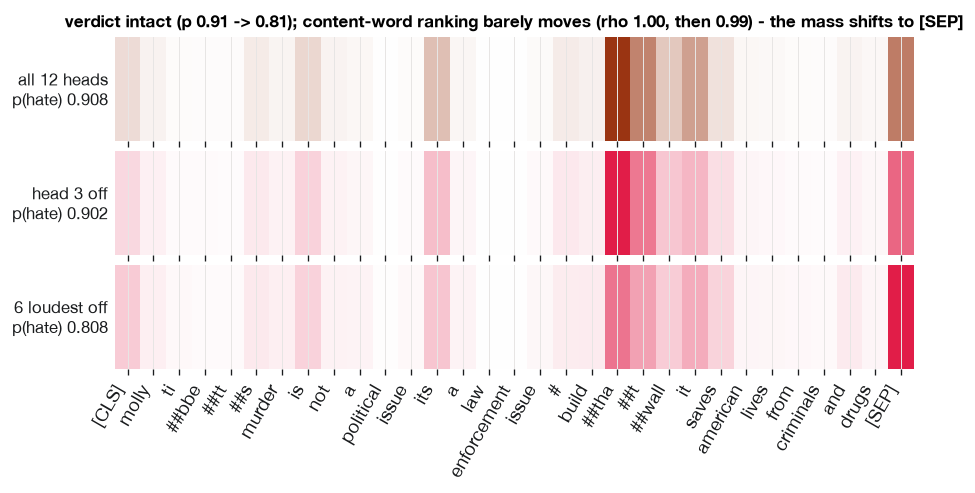

In [15]:
#| label: fig-scrambled-attention
#| fig-cap: "Head ablation on the showcase tweet (ablated rows in rose). The verdict survives losing the loudest head, and even half the final layer's heads; attention mass migrates toward [SEP]."
#| fig-alt: "Attention strips before and after head ablation on one tweet: the verdict survives deleting the loudest head and half the final layer while the leftover pattern shifts."
_i = records.index(show)
fig, axes = plt.subplots(3, 1, figsize=(7.6, 4.0), constrained_layout=True)
strip(axes[0], show["tokens"], cls_row(show["att"]), CM_RUST,
      f"all {NUM_HEADS} heads\np(hate) {show['probs'][1]:.3f}", show_tokens=False)
strip(axes[1], show["tokens"], show_abl["map1"], CM_ROSE,
      f"head {show_abl['head']} off\np(hate) {show_abl['p1']:.3f}", show_tokens=False)
strip(axes[2], show["tokens"], show_abl["map6"], CM_ROSE,
      f"{HALF} loudest off\np(hate) {show_abl['p6']:.3f}")
axes[0].set_title(
    f"verdict intact (p {show['probs'][1]:.2f} -> {show_abl['p6']:.2f}); content-word "
    f"ranking barely moves (rho {abl_df.loc[_i, 'rho_1']:.2f}, then "
    f"{abl_df.loc[_i, f'rho_{HALF}']:.2f}) - the mass shifts to [SEP]",
    fontsize=10)
plt.show()

## Interactive head view (BertViz)

Static strips compress; BertViz [@vig2019bertviz] lets you scrub every layer and head yourself, the fastest way to *feel* how much the maps disagree. The cell is off by default because the interactive HTML would add megabytes to the committed notebook: it runs automatically on Colab, or locally with `BOOK_BERTVIZ=1`.

In [16]:
if IN_COLAB or os.environ.get("BOOK_BERTVIZ") == "1":
    from bertviz import head_view

    with torch.no_grad():
        _bv = model(**show["enc"], output_attentions=True)
    head_view([a.cpu() for a in _bv.attentions], show["tokens"])
else:
    print("BertViz head view skipped, set BOOK_BERTVIZ=1 (or run on Colab) to render it.")

BertViz head view skipped, set BOOK_BERTVIZ=1 (or run on Colab) to render it.


## The attention admissibility checklist

Five tests an attention map must pass before it goes in front of a stakeholder. Each one is something this lab just did to the specimen. Run them on *your* model before you screenshot a heatmap:

1. **Aggregation robustness.** Does the token ranking survive switching layer and head aggregation? If three defensible collapses tell three stories, none of them is "the" story.
2. **Flow correction.** Does raw last-layer attention agree with a mixing-corrected view (rollout)? If not, the raw map is reading the wrong layer of the assembly line.
3. **Independent corroboration.** Does the map correlate with a gradient- or perturbation-based attribution on the same input? Weak ρ means the map is testimony from a single unreliable witness.
4. **Causal sensitivity.** If you ablate what the map says matters (here: the loudest head), does the prediction actually move? A map the model can lose without changing its verdict was decoration.
5. **Special-token discount.** How much mass sits on [CLS]/[SEP]/punctuation? Attention spent on housekeeping tokens is not evidence about *words*.

The scorecard below fills in the specimen's measured values.

In [17]:
print("Admissibility scorecard, ch04 specimen on HatEval validation tweets")
print("=" * 74)
print(f"1. aggregation robustness   worst pairwise rho across 3 aggregations: {AGG_RHO_MIN:.2f}")
print(f"2. flow correction          raw vs rollout rho: showcase {ROLL_VS_RAW_RHO:.2f}, "
      f"mean over tweets {rho_df['raw vs rollout'].mean():.2f}")
print(f"3. corroboration vs |IG|    raw {rho_df['raw (layer 6)'].mean():.2f} "
      f"\u00b1 {rho_df['raw (layer 6)'].std():.2f}, rollout {rho_df['rollout'].mean():.2f} "
      f"\u00b1 {rho_df['rollout'].std():.2f}")
print(f"4. causal sensitivity       loudest head off: mean |dp| {DP1_MEAN:.3f} (max "
      f"{DP1_MAX:.3f}); {HALF} heads off: mean |dp| {DP6_MEAN:.3f} (max {DP6_MAX:.3f}), "
      f"{FLIPS} label flips")
print(f"5. special-token discount   {SPECIAL_MASS:.0%} of [CLS] attention lands on "
      f"[CLS]/[SEP]")
print("=" * 74)
print("Verdict: on this specimen, attention is a window into *where information")
print("flows*, not a verdict on *why the model decided*, treat maps as leads to")
print("verify with attribution + ablation, never as standalone evidence.")

Admissibility scorecard, ch04 specimen on HatEval validation tweets
1. aggregation robustness   worst pairwise rho across 3 aggregations: -0.21
2. flow correction          raw vs rollout rho: showcase 0.66, mean over tweets 0.63
3. corroboration vs |IG|    raw 0.01 ± 0.40, rollout -0.01 ± 0.42
4. causal sensitivity       loudest head off: mean |dp| 0.007 (max 0.028); 6 heads off: mean |dp| 0.062 (max 0.100), 0 label flips
5. special-token discount   32% of [CLS] attention lands on [CLS]/[SEP]
Verdict: on this specimen, attention is a window into *where information
flows*, not a verdict on *why the model decided*, treat maps as leads to
verify with attribution + ablation, never as standalone evidence.


## Now try it on your own data

Run the same battery on a sentiment model (`distilbert-base-uncased-finetuned-sst-2-english` is a drop-in) and compare: does sentiment attention pass more of the checklist than hate-speech attention? (Sentiment cues are often single strong words, so tests 3 and 4 tend to behave differently.) The scaffold below runs when you set `BOOK_EXERCISE=1`; fill in the TODOs.

In [18]:
MY_MODEL = "distilbert-base-uncased-finetuned-sst-2-english"  # TODO: or your own checkpoint
MY_TEXTS = [
    "The film was a complete waste of two hours",          # TODO: replace with
    "An absolute triumph, I cried twice and laughed more",  # your own sentences
    "Mediocre plot saved by a stunning final act",
]

if os.environ.get("BOOK_EXERCISE") == "1":
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    tok_x = AutoTokenizer.from_pretrained(MY_MODEL)
    model_x = AutoModelForSequenceClassification.from_pretrained(
        MY_MODEL, attn_implementation="eager").to(DEVICE).eval()
    for text in MY_TEXTS:
        enc_x = tok_x(text, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out_x = model_x(**enc_x, output_attentions=True)
        att_x = torch.stack([a[0].cpu() for a in out_x.attentions])
        print(text, "->", out_x.logits.softmax(-1)[0].round(decimals=3).tolist())
        # TODO 1: plot cls_row(att_x) as a strip, which words light up?
        # TODO 2: rollout = attention_rollout(att_x)[0], does the ranking change?
        # TODO 3: Spearman rho vs LayerIntegratedGradients (reuse ig_token_scores
        #         with tok_x/model_x), higher or lower than the hate specimen?
        # TODO 4: ablate the loudest head with head_mask, does p(sentiment) move?
        # TODO 5: fill in the five-line scorecard for this model.
else:
    print("Set BOOK_EXERCISE=1 to run the sentiment-model scaffold.")

Set BOOK_EXERCISE=1 to run the sentiment-model scaffold.
